# Fase 8 (extra) — Estadística descriptiva, correlaciones y PCA sobre el panel histórico

Primer paso antes de armar clusters: entender la base completa.

Dataset: `data/processed/fbref_panel_2010_2025.csv` — 61,542 filas, 7 ligas
(Premier League, La Liga, Serie A, Bundesliga, Ligue 1, Eredivisie, Liga MX),
16 temporadas cada una (2010-11 a 2025-26). Cada fila es un jugador en una
temporada en una liga.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/processed/fbref_panel_2010_2025.csv")
print(df.shape)
df.head()

(61542, 26)


,ranker,player,nationality,position,team,age,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,league,season
0,1,Mohammed Abdellaoue,no NOR,FW,Hannover 96,24.0,1985.0,26,26,"2,086",23.2,10.0,1.0,11.0,10.0,0.0,0.0,1,0,0.43,0.04,0.47,0.43,0.47,Bundesliga,2010-2011
1,2,Yacine Abdessadki,ma MAR,MF,Freiburg,29.0,1981.0,21,20,"1,753",19.5,0.0,0.0,0.0,0.0,0.0,0.0,4,0,0.00,0.00,0.00,0.00,0.00,Bundesliga,2010-2011
2,3,Mathias Abel,de GER,DF,Kaiserslautern,29.0,1981.0,19,19,"1,663",18.5,2.0,0.0,2.0,2.0,0.0,0.0,4,0,0.11,0.00,0.11,0.11,0.11,Bundesliga,2010-2011
3,4,René Adler,de GER,GK,Leverkusen,25.0,1985.0,32,32,"2,880",32.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0,0.00,0.00,0.00,0.00,0.00,Bundesliga,2010-2011
4,5,David Alaba,at AUT,"DF,MF",Hoffenheim,18.0,1992.0,17,17,"1,530",17.0,2.0,1.0,3.0,2.0,0.0,0.0,3,0,0.12,0.06,0.18,0.12,0.18,Bundesliga,2010-2011


## Diccionario de datos y calidad

Antes de calcular nada, hay que ver qué tan completa está cada columna y
arreglar los tipos de dato que vinieron mal desde el scraping (`minutes`
llegó como texto con comas, ej. `"3,780"`).

In [2]:
df["minutes"] = df["minutes"].astype(str).str.replace(",", "", regex=False)
df["minutes"] = pd.to_numeric(df["minutes"], errors="coerce")

# Filtramos a jugadores con muestra mínima razonable (igual que en notebooks
# anteriores) para que las estadísticas no se distorsionen por suplentes con
# 1-2 partidos jugados.
regulares = df[df["minutes_90s"] >= 5].copy()

faltantes = regulares.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
print(f"{len(regulares)} filas regulares (de {len(df)} totales)\n")
print("Columnas con datos faltantes:")
faltantes

43285 filas regulares (de 61542 totales)

Columnas con datos faltantes:


nationality                 13
age                         10
birth_year                   8
position                     3
pens_att                     2
goals_assists_pens_per90     1
goals_pens_per90             1
goals_pens                   1
pens_made                    1
dtype: int64

In [3]:
metricas_numericas = [
    "age", "games", "games_starts", "minutes_90s",
    "goals", "assists", "goals_assists", "goals_pens",
    "cards_yellow", "cards_red",
    "goals_per90", "assists_per90", "goals_assists_per90", "goals_pens_per90",
]

regulares[metricas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
age,43275.0,25.857331,4.196499,15.0,23.00,26.00,29.00,44.00
games,43285.0,23.667691,8.294853,5.0,17.00,25.00,31.00,38.00
games_starts,43285.0,19.025159,9.357509,0.0,11.00,18.00,27.00,38.00
minutes_90s,43285.0,18.815800,8.859680,5.0,11.10,18.00,26.10,38.00
goals,43285.0,2.338108,3.649404,0.0,0.00,1.00,3.00,50.00
assists,43285.0,1.617881,2.179485,0.0,0.00,1.00,2.00,21.00
goals_assists,43285.0,3.955989,5.108908,0.0,1.00,2.00,5.00,66.00
goals_pens,43284.0,2.129909,3.234022,0.0,0.00,1.00,3.00,42.00
cards_yellow,43285.0,3.449671,2.769540,0.0,1.00,3.00,5.00,20.00
cards_red,43285.0,0.193462,0.462081,0.0,0.00,0.00,0.00,6.00


## Distribuciones

Goles y asistencias por 90 son variables de conteo raras (muchos jugadores
en cero, cola larga a la derecha) — no se comportan como una normal. Vale la
pena verlo antes de usar métodos que asumen linealidad/normalidad como PCA.

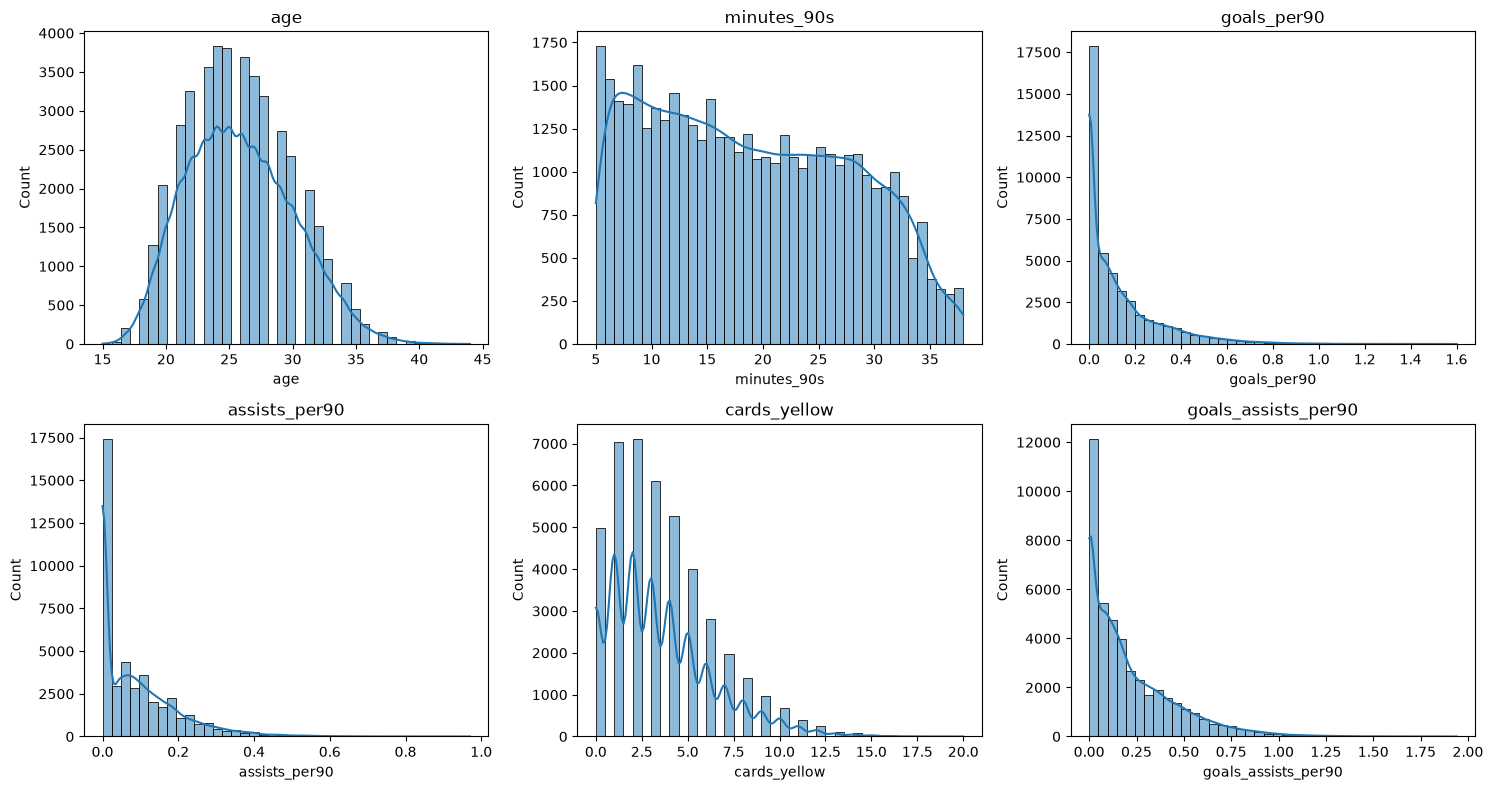

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols_dist = ["age", "minutes_90s", "goals_per90", "assists_per90", "cards_yellow", "goals_assists_per90"]
for ax, col in zip(axes.flat, cols_dist):
    sns.histplot(regulares[col].dropna(), ax=ax, bins=40, kde=True)
    ax.set_title(col)
fig.tight_layout()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Eredivisie'),
  Text(1, 0, 'Bundesliga'),
  Text(2, 0, 'Liga MX'),
  Text(3, 0, 'Ligue 1'),
  Text(4, 0, 'Premier League'),
  Text(5, 0, 'Serie A'),
  Text(6, 0, 'La Liga')])

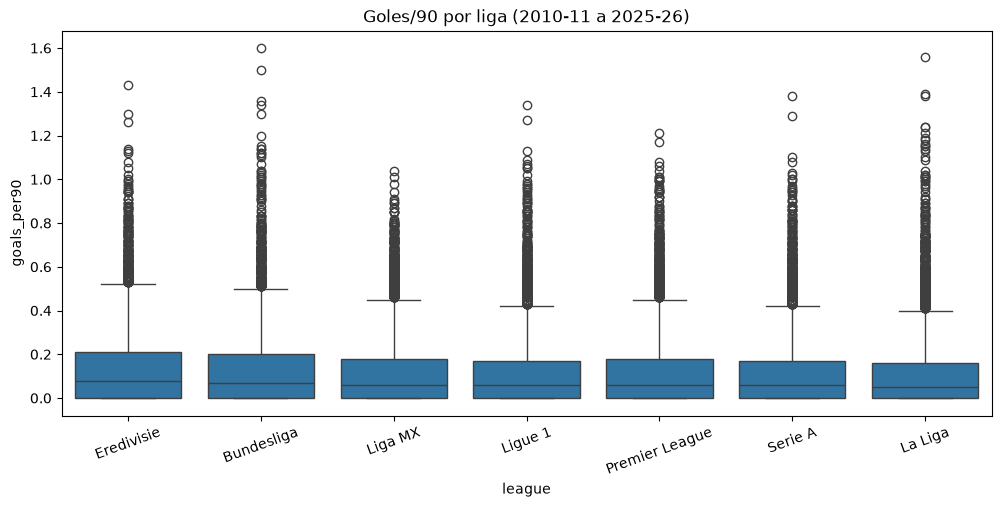

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
orden_ligas = regulares.groupby("league")["goals_per90"].median().sort_values(ascending=False).index
sns.boxplot(data=regulares, x="league", y="goals_per90", order=orden_ligas, ax=ax)
ax.set_title("Goles/90 por liga (2010-11 a 2025-26)")
plt.xticks(rotation=20)

## Matriz de correlación

**Nota metodológica importante**: la correlación *policórica* está diseñada
para variables **ordinales/categóricas** que se asume vienen de una
distribución normal latente subyacente (el caso típico es una escala tipo
Likert 1-5). Nuestras métricas (`goals_per90`, `assists_per90`, `age`,
`minutes_90s`, etc.) ya son **continuas o de conteo**, no ordinales — así que
la policórica no aplica directamente aquí y estaría mal usarla sobre estos
datos tal cual.

Lo que sí corresponde:
- **Pearson**: correlación lineal entre variables continuas.
- **Spearman**: correlación de rangos — más robusta cuando las variables no
  son normales (como goles/90, que tiene muchos ceros y cola larga).

Al final de esta sección dejamos, como bonus, una versión **policórica real**
sobre versiones categorizadas (ej. "nivel de goleador": bajo/medio/alto) por
si te interesa esa variante en vez de la continua.

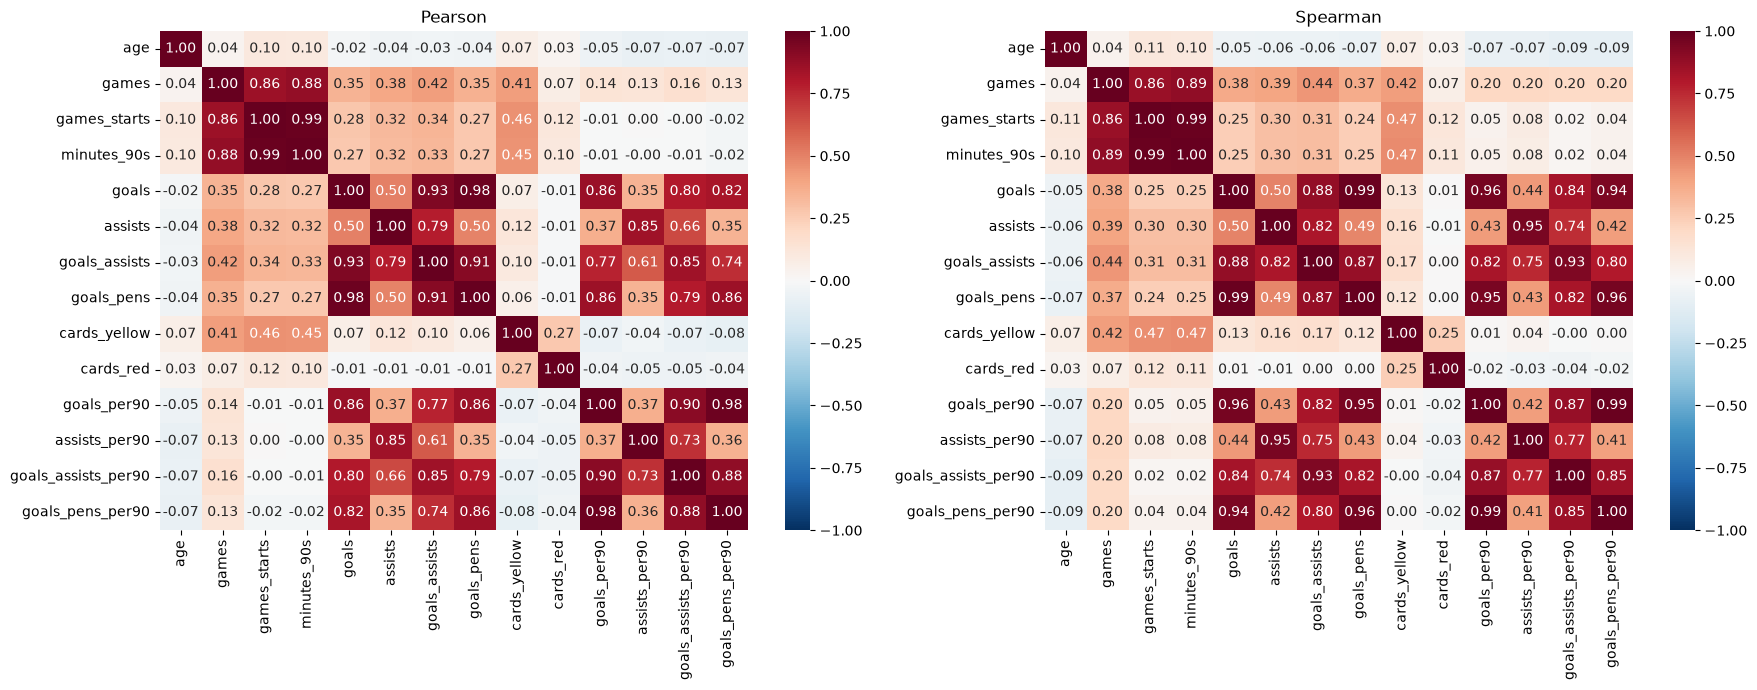

In [6]:
corr_pearson = regulares[metricas_numericas].corr(method="pearson")
corr_spearman = regulares[metricas_numericas].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman")
fig.tight_layout()

### Bonus: correlación policórica sobre versiones categorizadas

Si de verdad quieres la policórica (por ejemplo porque el análisis final va
a tratar estas métricas como niveles ordinales — "bajo/medio/alto" — en vez
de continuas), primero hay que discretizar. Aquí un ejemplo con terciles.
Requiere el paquete `semopy` o `polychoric` — si no lo tienes instalado,
corre `pip install polychoric` en el entorno.

In [7]:
cols_ordinal = ["goals_per90", "assists_per90", "cards_yellow", "minutes_90s"]
ordinal = regulares[cols_ordinal].apply(
    lambda s: pd.qcut(s.rank(method="first"), 3, labels=["bajo", "medio", "alto"])
)

try:
    from polychoric import polychoric_correlation_matrix
    ordinal_codes = ordinal.apply(lambda s: s.cat.codes)
    corr_poly = polychoric_correlation_matrix(ordinal_codes.values)
    corr_poly = pd.DataFrame(corr_poly, index=cols_ordinal, columns=cols_ordinal)
    sns.heatmap(corr_poly, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
    plt.title("Policórica (terciles bajo/medio/alto)")
except ImportError:
    print("Paquete 'polychoric' no instalado — corre: pip install polychoric")
    print("Mientras tanto, esto es lo que se comparó (terciles):")
    ordinal.head()

Paquete 'polychoric' no instalado — corre: pip install polychoric
Mientras tanto, esto es lo que se comparó (terciles):


## PCA sobre métricas per-90

Usamos las métricas ya normalizadas por minutos jugados (`_per90`) más edad,
estandarizadas (z-score), para encontrar los ejes principales de variación
en el rendimiento ofensivo/disciplinario. Esto es exactamente lo que
necesitaremos después para reducir dimensiones antes de hacer clustering.

43274 jugadores usados en el PCA


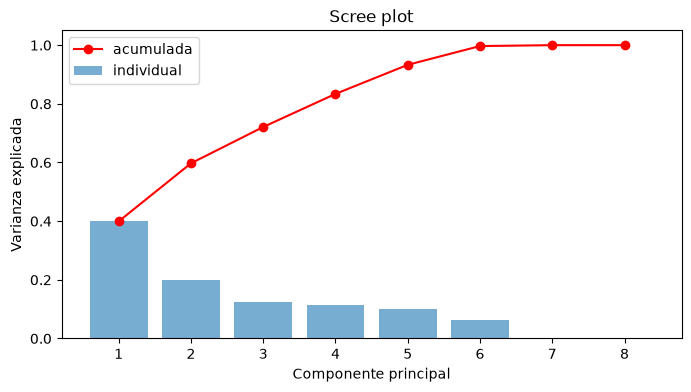

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cols_pca = [
    "age", "minutes_90s", "goals_per90", "assists_per90",
    "goals_assists_per90", "goals_pens_per90", "cards_yellow", "cards_red",
]
pca_df = regulares[cols_pca].dropna()

X = StandardScaler().fit_transform(pca_df)
pca = PCA(n_components=len(cols_pca))
componentes = pca.fit_transform(X)

varianza = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(varianza) + 1), varianza, alpha=0.6, label="individual")
ax.plot(range(1, len(varianza) + 1), np.cumsum(varianza), color="red", marker="o", label="acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza explicada")
ax.legend()
ax.set_title("Scree plot")
print(f"{len(pca_df)} jugadores usados en el PCA")

In [9]:
cargas = pd.DataFrame(
    pca.components_[:3].T, index=cols_pca, columns=["PC1", "PC2", "PC3"]
)
cargas.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)

,PC1,PC2,PC3
age,-0.062086,0.173580,0.912789
minutes_90s,-0.029958,0.606805,0.099589
goals_per90,0.526117,0.058125,0.061691
assists_per90,0.361666,0.036375,-0.075454
goals_assists_per90,0.553164,0.059414,0.010725
goals_pens_per90,0.522891,0.042201,0.040370
cards_yellow,-0.074447,0.654672,-0.114666
cards_red,-0.051944,0.403794,-0.364014


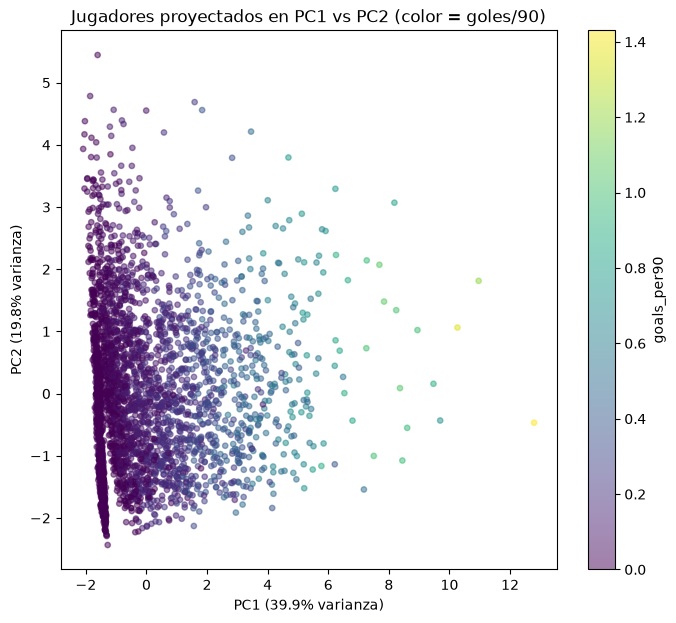

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
muestra = np.random.default_rng(42).choice(len(componentes), size=3000, replace=False)
scatter = ax.scatter(
    componentes[muestra, 0], componentes[muestra, 1],
    c=pca_df["goals_per90"].values[muestra], cmap="viridis", alpha=0.5, s=15,
)
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f}% varianza)")
ax.set_title("Jugadores proyectados en PC1 vs PC2 (color = goles/90)")
fig.colorbar(scatter, label="goals_per90")

## Foco en un jugador puntual, a través de las temporadas

Todo lo anterior es agregado — no dice nada de un jugador en concreto. Como
este dataset es un **panel** (mismo jugador aparece varias veces, una fila
por temporada), podemos hacer algo que antes no era posible con un solo
snapshot de temporada: ver la **trayectoria de carrera** de un jugador.

`jugador_foco` funciona igual que en `04` y `06` — cambia el nombre para ver
a otro jugador. Lewandowski es buen ejemplo por defecto porque tiene las 16
temporadas completas en el panel (Dortmund → Bayern → Barcelona).

In [11]:
jugador_foco = "Robert Lewandowski"  # cambia aquí para ver a otro jugador

trayectoria = regulares[regulares["player"] == jugador_foco].sort_values("season")
cols_trayectoria = ["season", "team", "league", "age", "minutes_90s", "goals_per90", "assists_per90", "goals_assists_per90"]
trayectoria[cols_trayectoria]

,season,team,league,age,minutes_90s,goals_per90,assists_per90,goals_assists_per90
261,2010-2011,Dortmund,Bundesliga,21.0,17.7,0.45,0.06,0.51
724,2011-2012,Dortmund,Bundesliga,22.0,31.9,0.69,0.22,0.91
1219,2012-2013,Dortmund,Bundesliga,23.0,28.8,0.83,0.17,1.01
1701,2013-2014,Dortmund,Bundesliga,24.0,31.1,0.64,0.26,0.90
2180,2014-2015,Bayern Munich,Bundesliga,25.0,27.6,0.62,0.18,0.80
2669,2015-2016,Bayern Munich,Bundesliga,26.0,29.5,1.02,0.07,1.09
3146,2016-2017,Bayern Munich,Bundesliga,27.0,30.8,0.97,0.16,1.14
3633,2017-2018,Bayern Munich,Bundesliga,28.0,24.1,1.20,0.08,1.28
4103,2018-2019,Bayern Munich,Bundesliga,29.0,32.9,0.67,0.21,0.88
4571,2019-2020,Bayern Munich,Bundesliga,30.0,30.7,1.11,0.13,1.24


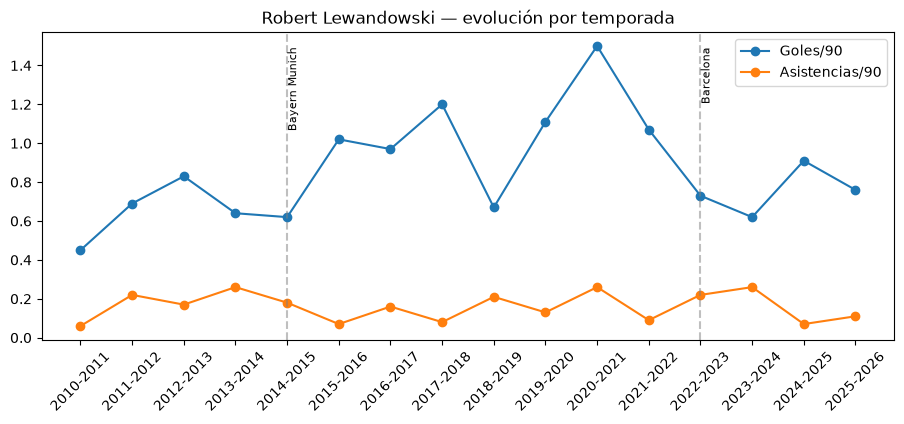

In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(trayectoria["season"], trayectoria["goals_per90"], marker="o", label="Goles/90")
ax.plot(trayectoria["season"], trayectoria["assists_per90"], marker="o", label="Asistencias/90")
ax.set_title(f"{jugador_foco} — evolución por temporada")
ax.legend()
plt.xticks(rotation=45)

# Marca los cambios de equipo con una línea vertical, para ver si coinciden
# con quiebres en el rendimiento.
cambios_equipo = trayectoria["team"] != trayectoria["team"].shift()
for _, fila in trayectoria[cambios_equipo].iloc[1:].iterrows():
    ax.axvline(fila["season"], color="grey", ls="--", alpha=0.5)
    ax.annotate(fila["team"], (fila["season"], ax.get_ylim()[1] * 0.95), rotation=90, fontsize=8, va="top")

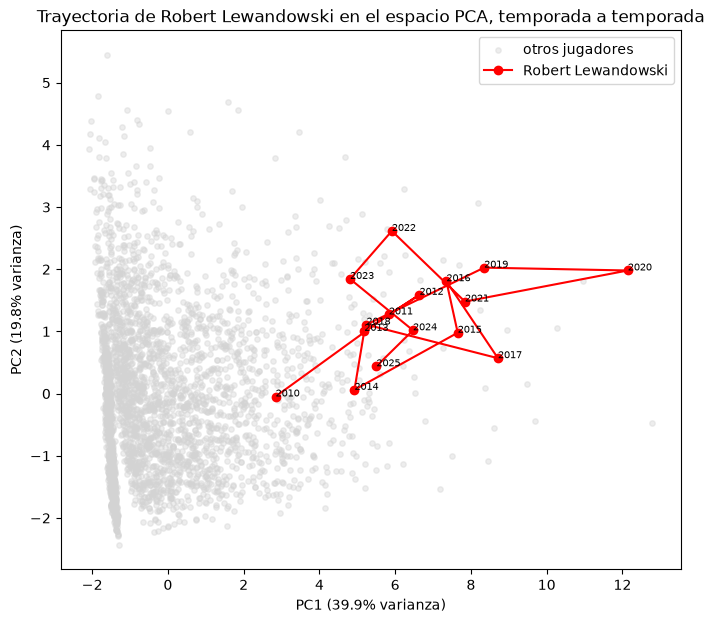

In [13]:
regulares_pca = regulares.loc[pca_df.index]  # mismo orden de filas que `componentes`

# Ordenamos cronológicamente las apariciones de jugador_foco ANTES de indexar
# a `componentes`, para que la línea y las etiquetas de temporada coincidan
# (el CSV no viene ordenado por jugador/temporada, viene por liga-temporada).
idx_foco_ordenado = regulares_pca[regulares_pca["player"] == jugador_foco].sort_values("season").index
posiciones = [regulares_pca.index.get_loc(i) for i in idx_foco_ordenado]
puntos_foco = componentes[posiciones][:, :2]  # solo PC1, PC2 para graficar
temporadas_foco = regulares_pca.loc[idx_foco_ordenado, "season"].values

fig, ax = plt.subplots(figsize=(8, 7))
muestra = np.random.default_rng(42).choice(len(componentes), size=3000, replace=False)
ax.scatter(componentes[muestra, 0], componentes[muestra, 1], color="lightgrey", alpha=0.4, s=15, label="otros jugadores")

ax.plot(puntos_foco[:, 0], puntos_foco[:, 1], color="red", marker="o", linewidth=1.5, label=jugador_foco)
for (x, y), temporada in zip(puntos_foco, temporadas_foco):
    ax.annotate(temporada[:4], (x, y), fontsize=7)

ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f}% varianza)")
ax.set_title(f"Trayectoria de {jugador_foco} en el espacio PCA, temporada a temporada")
ax.legend()

## Siguiente paso

Con esto ya tenemos:
- Calidad y forma de los datos (faltantes, distribuciones no-normales).
- Qué variables están correlacionadas entre sí (para no meter variables
  redundantes al clustering).
- Los componentes principales que capturan la mayoría de la varianza —
  candidatos directos para reducir dimensiones antes de aplicar K-Means o
  clustering jerárquico, agrupando por posición y comparando entre ligas.